# Purpose
This notebook generates figures and tables for the fitting to empirical connectomes (Fig 9, S25; Table 1, S1).

In [1]:
import pickle
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import sys
sys.path.append('..')
from scripts import draw, clean_data, stats_analysis#, indices

In [2]:
tau = 0.05
prand = 0.1
K = 20
binary_flag = True

In [3]:
f = open('./Output/Experimental Adj.pckl', 'rb')
A_real = pickle.load(f)
f.close()

In [4]:
A_sim = {}

pin = 0.78
A_sim['C.elegans'] = {}
for k in range(K):
    f = open('./Output/CE_Ain_pin_'+str(pin)+'_prand_'+str(prand)+'_tau_'+str(tau)+'_'+str(k)+'.pckl', 'rb')
    A_sim['C.elegans'][k], trunc_num = pickle.load(f)
    f.close()

pin = 0.15
A_sim['Mouse retina'] = {}
for k in range(K):
    f = open('./Output/MR_Cout_pin_'+str(pin)+'_prand_'+str(prand)+'_tau_'+str(tau)+'_'+str(k)+'.pckl', 'rb')
    A_sim['Mouse retina'][k], trunc_num = pickle.load(f)
    f.close()

# Table S1: properties of empirical connectomes

In [5]:
rows = []
for name, adj in A_real.items():
    n, edges, density, W, avg_w = clean_data.adjacency_stats(adj)
    rows.append({"name": name, "size": n, "# edges": edges, "density": density, "tot_weight": W, "avg_weight": avg_w})

df = pd.DataFrame(rows)
df

,name,size,# edges,density,tot_weight,avg_weight
0,C.elegans,185,5245,0.154083,12216.308850,2.329134
1,Mouse retina,1076,90009,0.077815,96747.719176,1.074867


In [6]:
f = open('./Output/Table S1.pckl', 'wb')
pickle.dump(df, f)
f.close()

# Fig 9:  Weight distributions of simulated networks fit the empirical connectomes

In [7]:
f = open('./Output/hubs.pckl', 'rb')
con_num, real_con_num, div_num, real_div_num = pickle.load(f)
f.close()

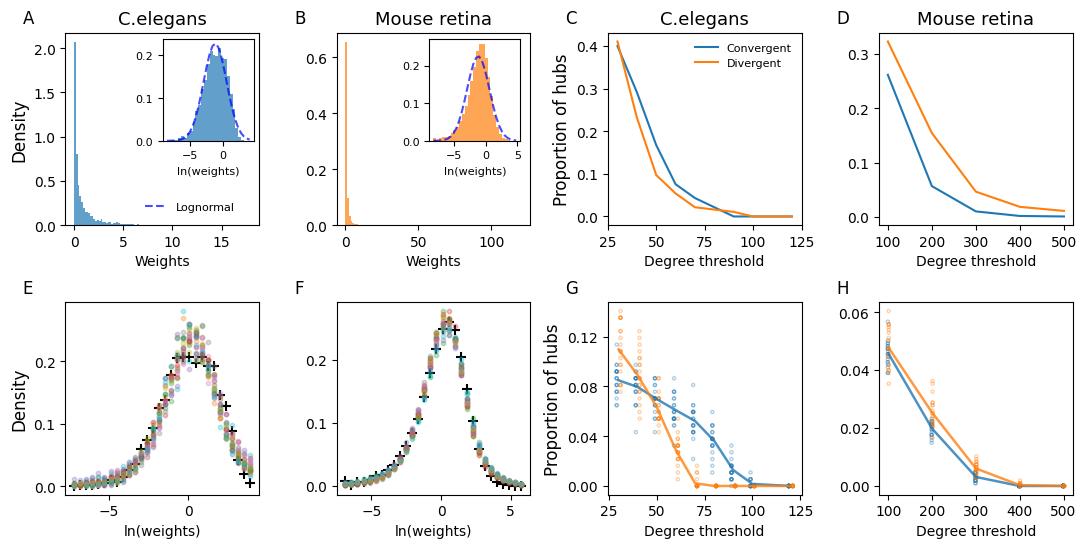

In [8]:
plt.rcParams["figure.figsize"] = (13, 6)
fig, ax1 = plt.subplots(2, 4)

thresh_ls = {}
thresh_ls['C.elegans'] = [30, 40, 50, 60, 70, 80, 90, 100, 120]
thresh_ls['Mouse retina'] = [100, 200, 300, 400, 500]

# weight distributions of empirical connectomes
for i, key in enumerate(A_real.keys()):
    weights = A_real[key][A_real[key]>0]
    weights = weights/np.mean(weights)
    ax1[0, i].hist(weights, bins=100, density=True, color = sns.color_palette(palette='tab10', n_colors=5)[i], alpha=0.7)
    ax1[0, i].set_title(key, fontsize = 13)
    ax1[0, i].set_xlabel('Weights',fontsize=10)
    ax1[0, i].tick_params(axis = 'both', labelsize=10)
    
    left, bottom, width, height = [0.2+i*0.205, 0.7, 0.07, 0.17]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    x, mu, sig = draw.hist_log_weight(ax1_1, weights, num_bins = 30, color = sns.color_palette(palette='tab10', n_colors=3)[i])
    
    ylog = stats.norm.pdf(x, loc=mu, scale=sig)  
    ax1_1.plot(x, ylog, color='b', linestyle='dashed',alpha=0.7, label = 'Lognormal')
    if i == 0:
        ax1_1.legend(fontsize = 8, frameon=False, bbox_to_anchor=(0.9, -0.5))
ax1[0, 0].set_ylabel('Density',fontsize=12) 

# num of hubs of empirical connectomes
for i, key in enumerate(real_con_num.keys()):
    ax1[0, i+2].plot(thresh_ls[key], real_con_num[key], label='Convergent')
    ax1[0, i+2].plot(thresh_ls[key], real_div_num[key], label='Divergent')
    ax1[0, i+2].set_title(key, fontsize = 13)
    ax1[0, i+2].set_xlabel('Degree threshold')
ax1[0, 2].set_ylabel('Proportion of hubs',fontsize=12)  
ax1[0, 2].legend(frameon = False, fontsize = 8)

for i, key in enumerate(A_real.keys()):
    # distributions of log(weight) of empirical connectomes, centered at 0
    log_w = stats_analysis.zero_centered(A_real[key])
    counts, bins = np.histogram(log_w, bins=30, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bc = bin_centers[counts>0]; cc = counts[counts>0]
    ax1[1, i].scatter(bc, cc, color='k', marker='+', s = 50)

    # distributions of log(weight) of simulated connectomes, centered at 0
    for k in A_sim[key].keys():  
        log_wsim_temp = stats_analysis.zero_centered(A_sim[key][k])
        counts, bins = np.histogram(log_wsim_temp, bins=bins, density=True)
        bc = bin_centers[counts>0]; cc = counts[counts>0]
        ax1[1, i].scatter(bc, cc, s = 10, alpha = 0.3)
    ax1[1, i].set_xlabel('ln(weights)',fontsize=10)

    # num of hubs of simulated connectomes
    draw.draw_mean_scatter(ax1[1, i+2], thresh_ls[key], con_num[key], color =  sns.color_palette(palette='tab10')[0], shift = 1, jitter = 0.02)
    draw.draw_mean_scatter(ax1[1, i+2], thresh_ls[key], div_num[key], color =  sns.color_palette(palette='tab10')[1], shift = -1, jitter = 0.02)
    ax1[1, i+2].set_xlabel('Degree threshold')
    
ax1[1, 2].set_yticks([0, 0.04, 0.08,0.12])
ax1[1, 0].set_ylabel('Density',fontsize=12)
ax1[1, 2].set_ylabel('Proportion of hubs',fontsize=12)  
ax1[1, 0].set_ylabel('Density',fontsize=12)
ax1[1, 2].set_ylabel('Proportion of hubs',fontsize=12)  

ax1[0, 2].set_xticks([25, 50, 75, 100, 125])
ax1[1, 2].set_xticks([25, 50, 75, 100, 125])
ax1[0, 3].set_xticks([100, 200, 300, 400, 500])
ax1[1, 3].set_xticks([100, 200, 300, 400, 500])

ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[0, 1].text(-0.22, 1.05, 'B', transform=ax1[0, 1].transAxes, size=12)
ax1[0, 2].text(-0.22, 1.05, 'C', transform=ax1[0, 2].transAxes, size=12)
ax1[0, 3].text(-0.22, 1.05, 'D', transform=ax1[0, 3].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'E', transform=ax1[1, 0].transAxes, size=12)
ax1[1, 1].text(-0.22, 1.05, 'F', transform=ax1[1, 1].transAxes, size=12)
ax1[1, 2].text(-0.22, 1.05, 'G', transform=ax1[1, 2].transAxes, size=12)
ax1[1, 3].text(-0.22, 1.05, 'H', transform=ax1[1, 3].transAxes, size=12)

fig.subplots_adjust(wspace = 0.4, hspace = 0.4)
#plt.savefig('../fig/Fig 9.svg', dpi = 300)

# Table 1: average density and weight of intermediate subgraphs of emiprical and simulated networks

In [9]:
f = open('./Output/interm_stats.pckl', 'rb')
subG_density, real_subG_density, subG_aveW, real_subG_aveW = pickle.load(f)
f.close()

In [10]:
rows = []
for name, adj in A_real.items():
    rows.append({"name": name, "Density (Real)": round(real_subG_density[name], 2), 
                 "Density (Model)": round(np.mean(subG_density[name]), 2).astype(str) + " ± " + round(np.std(subG_density[name]), 2).astype(str), 
                 "Weight (Real)": round(real_subG_aveW[name], 2), 
                 "Weight (Model)": round(np.mean(subG_aveW[name]), 2).astype(str) + " ± " + round(np.std(subG_aveW[name]), 2).astype(str)})

tab1= pd.DataFrame(rows)
tab1

,name,Density (Real),Density (Model),Weight (Real),Weight (Model)
0,C.elegans,2.31,1.41 ± 0.45,2.04,2.78 ± 1.4
1,Mouse retina,5.20,1.11 ± 0.19,1.35,2.38 ± 0.98


In [11]:
# test if average density and weight of intermediate subgraphs of simulated networks are higher than network-wide averages
p_density = {}; p_aveW = {}
for i, key in enumerate(A_real.keys()):
    res = stats.wilcoxon(subG_density[key] - 1, alternative='greater')
    p_density[key] = res.pvalue
    res = stats.wilcoxon(subG_aveW[key] - 1, alternative='greater')
    p_aveW[key] = res.pvalue
f = open('./Output/interm_pvalues.pckl', 'wb')
pickle.dump([p_density, p_aveW], f)
f.close()

In [12]:
p_density, p_aveW

({'C.elegans': 5.245208740234375e-05, 'Mouse retina': 0.022027015686035156},
 {'C.elegans': 9.5367431640625e-06, 'Mouse retina': 1.9073486328125e-06})

# Fig S25: Stationary analysis

In [13]:
f = open('./Output_long/summary_stats_evol.pckl', 'rb')
std, skew, kurt = pickle.load(f)
f.close()

f = open('./Output_long/Topo_metrics_evol.pckl', 'rb')
cc, ae, mod = pickle.load(f)
f.close()

In [14]:
std.keys()

dict_keys(['C.elegans', 'Mouse retina'])

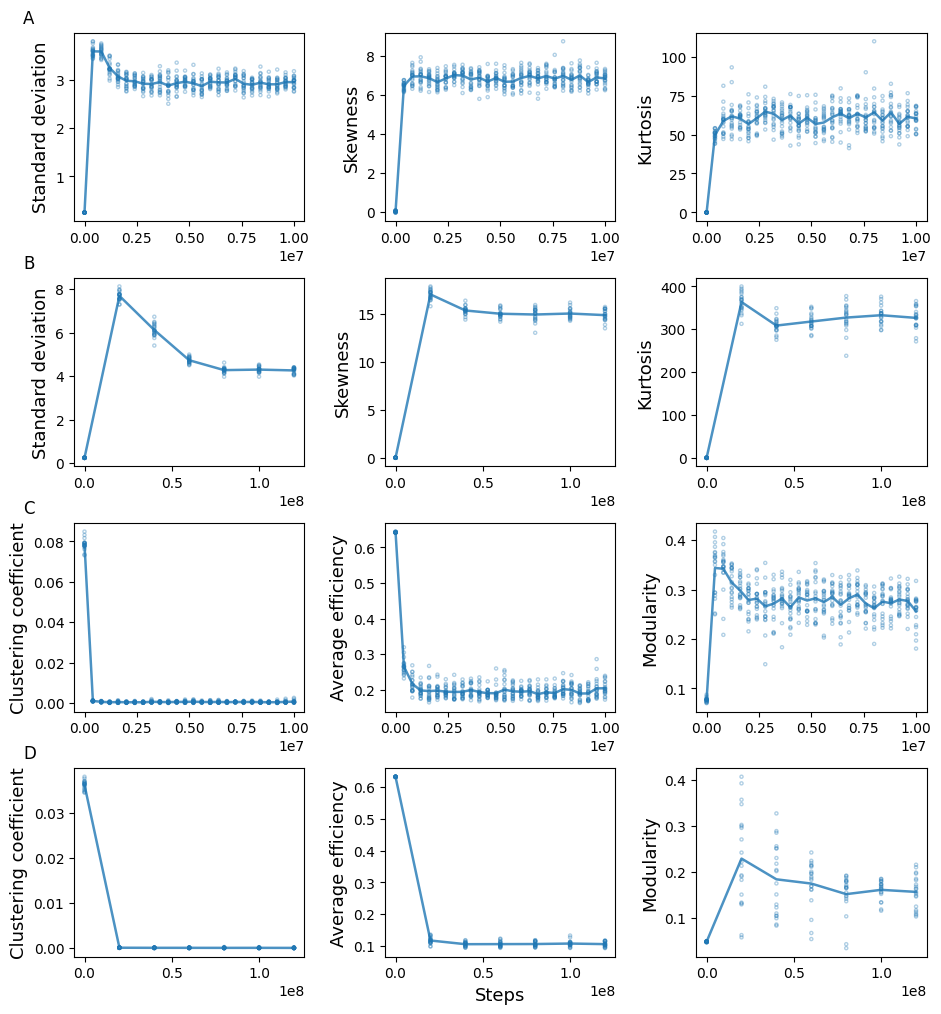

In [15]:
plt.rcParams["figure.figsize"] = (11, 12)
fig, ax1 = plt.subplots(4, 3)
for l, key in enumerate(std.keys()):
    draw.draw_mean_scatter(ax1[l, 0], list(std[key].keys()), std[key], color = sns.color_palette(palette='tab10', n_colors=3)[0], 
                           shift = 0, jitter = 1)
    draw.draw_mean_scatter(ax1[l, 1], list(skew[key].keys()), skew[key], color = sns.color_palette(palette='tab10', n_colors=3)[0], 
                           shift = 0, jitter = 1)
    draw.draw_mean_scatter(ax1[l, 2], list(kurt[key].keys()), kurt[key], color = sns.color_palette(palette='tab10', n_colors=3)[0], 
                           shift = 0, jitter = 1)
    draw.draw_mean_scatter(ax1[l+2, 0], list(cc[key].keys()), cc[key], color = sns.color_palette(palette='tab10', n_colors=3)[0], 
                           shift = 0, jitter = 1)
    draw.draw_mean_scatter(ax1[l+2, 1], list(ae[key].keys()), ae[key], color = sns.color_palette(palette='tab10', n_colors=3)[0], 
                           shift = 0, jitter = 1)
    draw.draw_mean_scatter(ax1[l+2, 2], list(mod[key].keys()), mod[key], color = sns.color_palette(palette='tab10', n_colors=3)[0], 
                           shift = 0, jitter = 1)
        
    ax1[l, 0].set_ylabel('Standard deviation', fontsize = 13)
    ax1[l, 1].set_ylabel('Skewness', fontsize = 13)
    ax1[l, 2].set_ylabel('Kurtosis', fontsize = 13)
    ax1[l+2, 0].set_ylabel('Clustering coefficient', fontsize = 13)
    ax1[l+2, 1].set_ylabel('Average efficiency', fontsize = 13)
    ax1[l+2, 2].set_ylabel('Modularity', fontsize = 13)

ax1[3, 1].set_xlabel('Steps', fontsize = 13)

ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
ax1[2, 0].text(-0.22, 1.05, 'C', transform=ax1[2, 0].transAxes, size=12)
ax1[3, 0].text(-0.22, 1.05, 'D', transform=ax1[3, 0].transAxes, size=12)

fig.subplots_adjust(wspace = 0.35, hspace = 0.3)
#plt.savefig('../fig/Fig S25.svg', dpi = 300)